In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
np.random.seed(42)

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)

print("\nInfo:")
df.info()

print("\nStatistics:")
print(df.describe())

print("\nMissing (real NaN):")
print(df.isnull().sum())

print("\nZeros per column (fake missing):")
print((df == 0).sum())

print("\nTarget distribution:")
print(df['Outcome'].value_counts())
print(f"Diabetes rate: {df['Outcome'].mean()*100:.2f}%")

DATA OVERVIEW

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.

In [6]:
zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[zero_invalid] = df[zero_invalid].replace(0, np.nan)

print("Missing values after replacing zeros:")
print(df.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


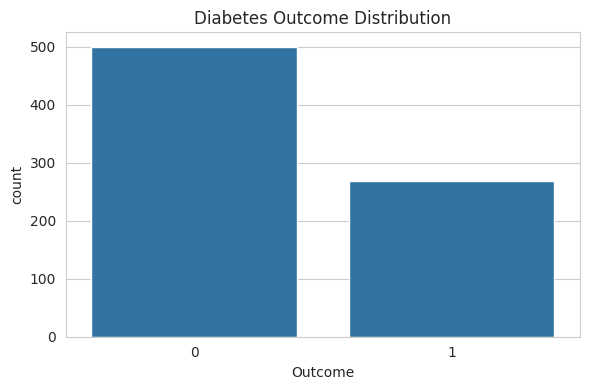

In [7]:
# 5a — Class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Distribution')
plt.tight_layout()
plt.show()

In [8]:
# Interaction features
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Glucose_Age'] = df['Glucose'] * df['Age']
df['BMI_Age']     = df['BMI'] * df['Age']

# Composite risk score
df['RiskScore'] = (df['Glucose']/100) + (df['BMI']/30) + (df['Age']/40)

# Binary flags
df['High_Glucose'] = (df['Glucose'] > 140).astype(int)
df['Obese']        = (df['BMI'] >= 30).astype(int)
df['Older']        = (df['Age'] > 40).astype(int)

print("Shape after feature engineering:", df.shape)
print("New columns added:",
      ['Glucose_BMI', 'Glucose_Age', 'BMI_Age',
       'RiskScore', 'High_Glucose', 'Obese', 'Older'])

Shape after feature engineering: (768, 16)
New columns added: ['Glucose_BMI', 'Glucose_Age', 'BMI_Age', 'RiskScore', 'High_Glucose', 'Obese', 'Older']


In [9]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test  class balance:\n{y_test.value_counts(normalize=True).round(3)}")

X_train shape: (614, 15)
X_test  shape: (154, 15)
Train class balance:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64
Test  class balance:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [10]:
xgb_pipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=0.1,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

print("✅ XGBoost pipeline ready")

✅ XGBoost pipeline ready


In [11]:
param_grid = {
    'clf__n_estimators':     [300, 500],
    'clf__max_depth':        [3, 4, 5],
    'clf__learning_rate':    [0.03, 0.05],
    'clf__subsample':        [0.8, 0.9],
    'clf__colsample_bytree': [0.8, 0.9],
    'clf__gamma':            [0, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best parameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.9}
Best CV accuracy: 0.7654


In [12]:
best_model = grid.best_estimator_

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("FINAL XGBOOST RESULTS ON TEST SET")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['No Diabetes', 'Diabetes']))

FINAL XGBOOST RESULTS ON TEST SET
Accuracy : 0.7403
Precision: 0.6400
Recall   : 0.5926
F1 Score : 0.6154
ROC-AUC  : 0.8196

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.82      0.80       100
    Diabetes       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



<Figure size 600x500 with 0 Axes>

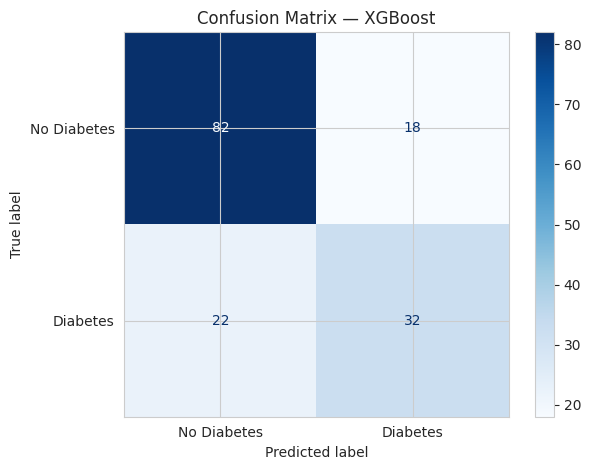

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
    cmap='Blues', values_format='d')
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

In [14]:
with open('diabetes_xgboost.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Model saved as 'diabetes_xgboost.pkl'")

✅ Model saved as 'diabetes_xgboost.pkl'


In [15]:
loaded_model = pickle.load(open('diabetes_xgboost.pkl', 'rb'))

new_patient = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 148,
    'BloodPressure': 72,
    'SkinThickness': 35,
    'Insulin': 120,
    'BMI': 33.6,
    'DiabetesPedigreeFunction': 0.627,
    'Age': 50,
    'Glucose_BMI': 148 * 33.6,
    'Glucose_Age': 148 * 50,
    'BMI_Age': 33.6 * 50,
    'RiskScore': (148/100) + (33.6/30) + (50/40),
    'High_Glucose': 1,
    'Obese': 1,
    'Older': 1
}])

prediction  = loaded_model.predict(new_patient)[0]
probability = loaded_model.predict_proba(new_patient)[0, 1]

print("=" * 60)
print("PREDICTION FOR NEW PATIENT")
print("=" * 60)
print(f"Prediction : {'DIABETIC ⚠️' if prediction == 1 else 'NOT DIABETIC ✅'}")
print(f"Probability: {probability:.2%}")

PREDICTION FOR NEW PATIENT
Prediction : DIABETIC ⚠️
Probability: 74.20%


In [16]:
print("=" * 60)
print("FINAL SUMMARY — XGBoost Diabetes Predictor")
print("=" * 60)
print(f"Dataset        : diabetes.csv (768 patients, 9 raw features)")
print(f"Engineered     : 7 new features → 16 total")
print(f"Model          : XGBoost + KNN Imputation")
print(f"Best params    : {grid.best_params_}")
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred):.2%}")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Top features   : Glucose, Glucose_BMI, RiskScore, BMI")
print(f"Saved as       : diabetes_xgboost.pkl")
print("=" * 60)

FINAL SUMMARY — XGBoost Diabetes Predictor
Dataset        : diabetes.csv (768 patients, 9 raw features)
Engineered     : 7 new features → 16 total
Model          : XGBoost + KNN Imputation
Best params    : {'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.9}
Test Accuracy  : 74.03%
ROC-AUC        : 0.8196
Top features   : Glucose, Glucose_BMI, RiskScore, BMI
Saved as       : diabetes_xgboost.pkl
